In [ ]:
def get_track(df, energy, ion_number):
    """Return a DataFrame containing a single centered track."""
    return df[(df.energy == energy) & (df.ion_number == ion_number)]


import matplotlib.pyplot as plt

def plot_track_2d(df, energy, ion_number, ax=None):
    track = get_track(df, energy, ion_number)
    if len(track) == 0:
        raise ValueError("No track found for that energy & ion number.")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    x = track.x.values
    z = track.z.values
    parity = int(track.parity.iloc[0])

    color = "red" if parity == 0 else "blue"
    label = f"Track {ion_number} (parity {parity})"

    ax.plot(x, z, "o-", markersize=4, color=color, label=label)
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_title(f"Energy {energy} keV — 2D Track {ion_number}")
    ax.axvline(0, color='k', linewidth=1)
    ax.axhline(0, color='k', linewidth=1)
    ax.legend()

    return ax



from mpl_toolkits.mplot3d import Axes3D

def plot_track_3d(df, energy, ion_number):
    track = get_track(df, energy, ion_number)
    if len(track) == 0:
        raise ValueError("No track found for that energy & ion number.")
    
    x = track.x.values
    y = track.y.values
    z = track.z.values
    parity = int(track.parity.iloc[0])

    color = "red" if parity == 0 else "blue"
    label = f"Track {ion_number} (parity {parity})"

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(x, y, z, "o-", markersize=5, color=color, label=label)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"Energy {energy} keV — 3D Track {ion_number}")
    ax.legend()

    return ax

def compare_tracks_2d(df, energy, ion1, ion2):
    fig, ax = plt.subplots(figsize=(7,7))

    plot_track_2d(df, energy, ion1, ax=ax)
    plot_track_2d(df, energy, ion2, ax=ax)

    ax.set_title(f"Energy {energy} keV — Compare Track {ion1} vs {ion2}")
    plt.show()

def compare_tracks_3d(df, energy, ion1, ion2):
    track1 = df[(df.energy == energy) & (df.ion_number == ion1)]
    track2 = df[(df.energy == energy) & (df.ion_number == ion2)]

    fig = plt.figure(figsize=(9,9))
    ax = fig.add_subplot(111, projection='3d')

    for track, ion, color in [(track1, ion1, "red"), (track2, ion2, "blue")]:
        x, y, z = track.x.values, track.y.values, track.z.values
        parity = int(track.parity.iloc[0])
        ax.plot(x, y, z, "o-", color=color, label=f"Track {ion} (parity {parity})")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"Energy {energy} keV — Compare Track {ion1} vs {ion2}")
    ax.legend()
    return fig


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_multiple_tracks_3d(df, energy, ion_list):
    fig = plt.figure(figsize=(9,9))
    ax = fig.add_subplot(111, projection='3d')

    for ion in ion_list:
        track = df[(df.energy == energy) & (df.ion_number == ion)]
        if len(track) == 0:
            continue

        x, y, z = track.x.values, track.y.values, track.z.values
        parity = int(track.parity.iloc[0])
        color = "red" if parity == 0 else "blue"

        ax.plot(x, y, z, "o-", markersize=4,
                label=f"Ion {ion} (parity {parity})",
                color=color)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"Energy {energy} keV — Selected Tracks")
    ax.legend()
    plt.show()
    


In [30]:
%matplotlib widget

ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

In [2]:
import pandas as pd

path = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/centered_tracks.csv"
df = pd.read_csv(path)

In [3]:
df.energy.unique()

array([  1. ,   2.5,   5. ,   7.5,  10. ,  15. ,  20. ,  25. ,  30. ,
        35. ,  40. ,  45. ,  50. ,  55. ,  60. ,  65. ,  70. ,  75. ,
        80. ,  85. ,  90. ,  95. , 100. ])

In [4]:
df[df.energy == 10].ion_number.unique()[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

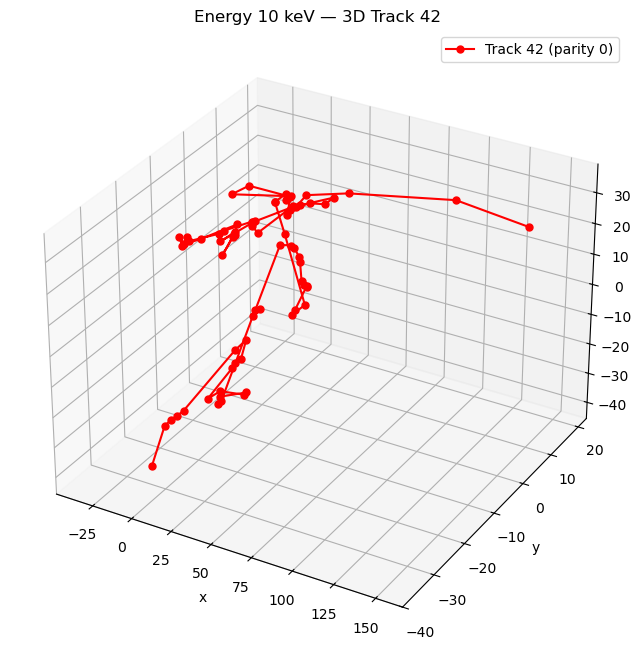

In [5]:
plot_track_3d(df, energy=10, ion_number=42)
plt.show()

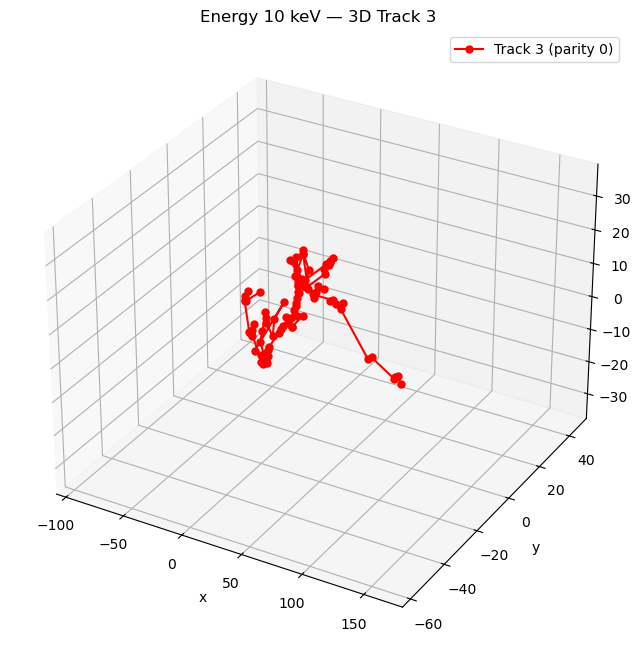

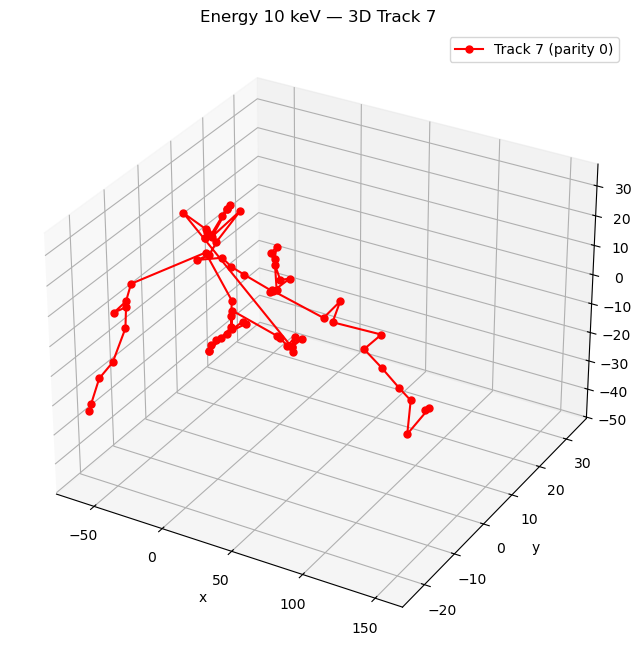

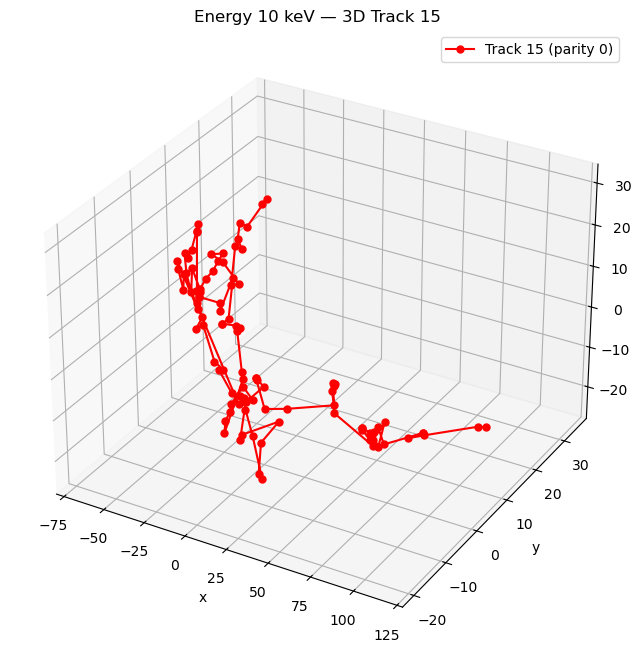

In [6]:
ions = [3, 7, 15]

for ion in ions:
    plot_track_3d(df, energy=10, ion_number=ion)
    plt.show()

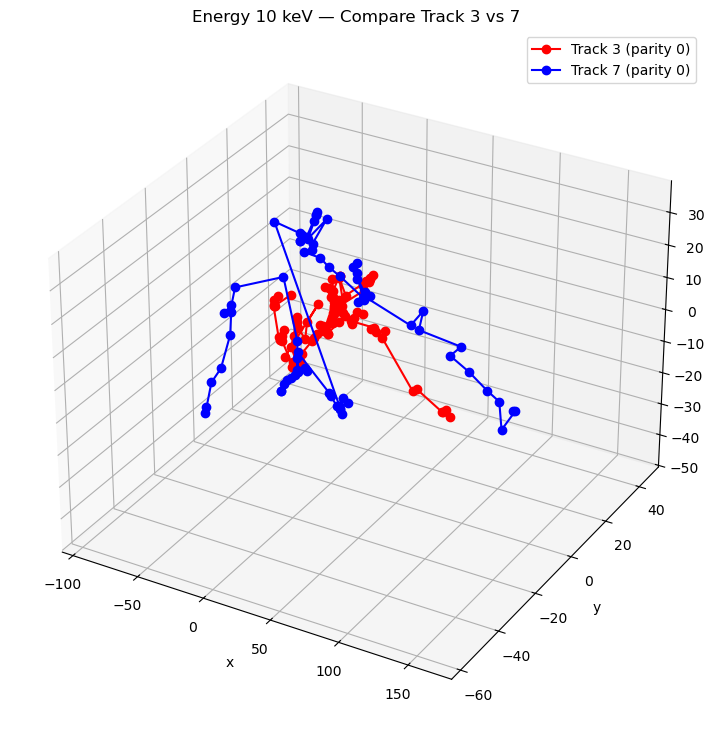

In [7]:
compare_tracks_3d(df, energy=10, ion1=3, ion2=7)

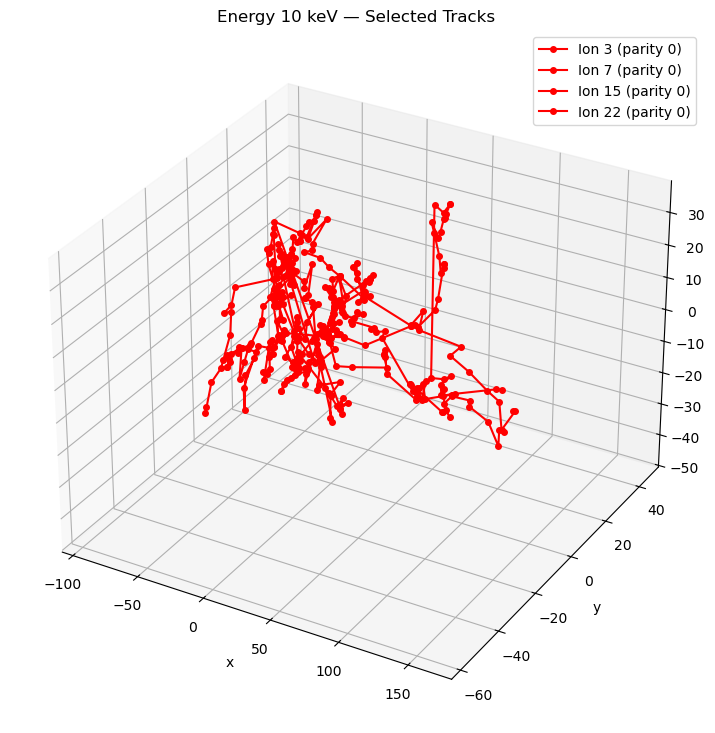

In [9]:
plot_multiple_tracks_3d(df, energy=10, ion_list=[3, 7, 15, 22])

In [10]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

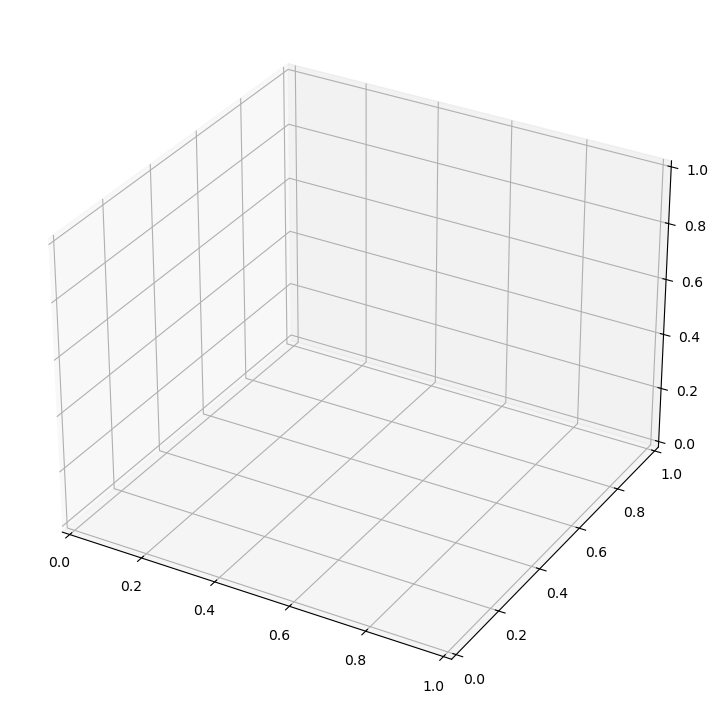

In [ ]:
energies = sorted(df.energy.unique())
energy_widget = widgets.Dropdown(
    options=energies,
    description="Energy (keV):"
)

ion_widget = widgets.Dropdown(
    options=[],
    description="Ion:"
)

In [12]:
def update_ions(change):
    energy = change["new"]
    ions = sorted(df[df.energy == energy].ion_number.unique())
    ion_widget.options = ions

energy_widget.observe(update_ions, names="value")
energy_widget.value = energies[0]

In [13]:
def interactive_plot(energy, ion_number):
    plt.close("all")
    plot_track_3d(df, energy, ion_number)
    plt.show()

ui = widgets.VBox([energy_widget, ion_widget])
out = widgets.interactive_output(
    interactive_plot,
    {"energy": energy_widget, "ion_number": ion_widget}
)

display(ui, out)

Output()

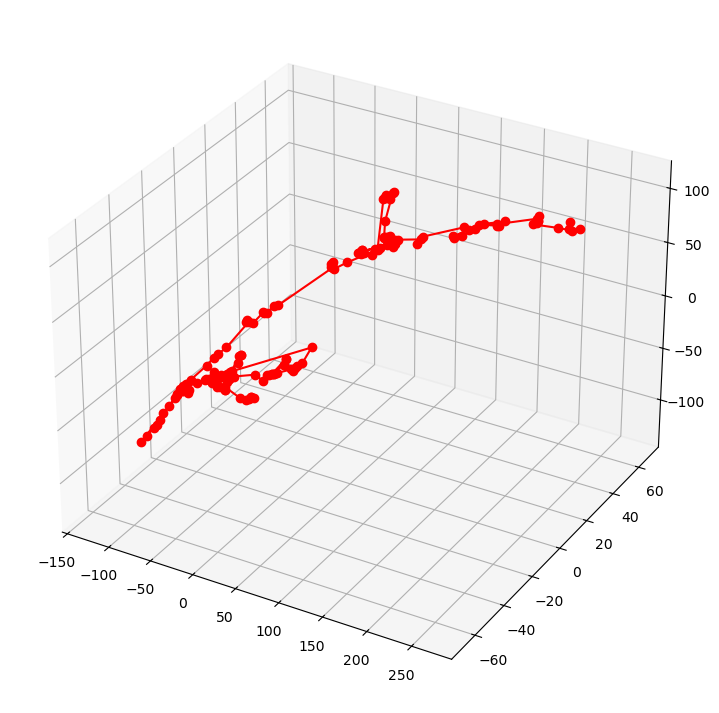

In [14]:
ion1 = widgets.Dropdown(description="Ion 1:")
ion2 = widgets.Dropdown(description="Ion 2:")

def update_compare_ions(change):
    energy = change["new"]
    ions = sorted(df[df.energy == energy].ion_number.unique())
    ion1.options = ions
    ion2.options = ions

energy_widget.observe(update_compare_ions, names="value")

In [17]:


def interactive_compare(energy, ion1, ion2):
    plt.close("all")
    fig = compare_tracks_3d(df, energy, ion1, ion2)
    display(fig)

display(
    widgets.VBox([energy_widget, ion1, ion2]),
    widgets.interactive_output(
        interactive_compare,
        {"energy": energy_widget, "ion1": ion1, "ion2": ion2}
    )
)

Output()

In [24]:
import numpy as np
track = get_track(df, energy=30.0, ion_number=6)


x = track.x.values
y = track.y.values
z = track.z.values

In [25]:
def bin_track_3d(track, n_bins=2):
    x, y, z = track.x.values, track.y.values, track.z.values

    x_edges = np.linspace(x.min(), x.max(), n_bins + 1)
    y_edges = np.linspace(y.min(), y.max(), n_bins + 1)
    z_edges = np.linspace(z.min(), z.max(), n_bins + 1)

    xb = np.digitize(x, x_edges) - 1
    yb = np.digitize(y, y_edges) - 1
    zb = np.digitize(z, z_edges) - 1

    vox = np.zeros((n_bins, n_bins, n_bins))

    for i, j, k in zip(xb, yb, zb):
        if 0 <= i < n_bins and 0 <= j < n_bins and 0 <= k < n_bins:
            vox[i, j, k] += 1

    return vox

In [26]:
voxels = bin_track_3d(track, n_bins=2)
voxels.flatten()

array([59., 11.,  0., 56.,  0., 12.,  1., 12.])

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import display

# ---------- helper: draw a single voxel ----------
def draw_voxel(ax, x0, x1, y0, y1, z0, z1, color="gray", alpha=0.15):
    verts = [
        [(x0,y0,z0),(x1,y0,z0),(x1,y1,z0),(x0,y1,z0)],
        [(x0,y0,z1),(x1,y0,z1),(x1,y1,z1),(x0,y1,z1)],
        [(x0,y0,z0),(x1,y0,z0),(x1,y0,z1),(x0,y0,z1)],
        [(x0,y1,z0),(x1,y1,z0),(x1,y1,z1),(x0,y1,z1)],
        [(x0,y0,z0),(x0,y1,z0),(x0,y1,z1),(x0,y0,z1)],
        [(x1,y0,z0),(x1,y1,z0),(x1,y1,z1),(x1,y0,z1)],
    ]
    ax.add_collection3d(
        Poly3DCollection(verts, facecolors=color, alpha=alpha, edgecolor="k")
    )

# ---------- main plotting function ----------
def plot_track_with_voxels(df, energy, ion):
    plt.close("all")

    track = df[(df.energy == energy) & (df.ion_number == ion)]
    if len(track) == 0:
        return

    x, y, z = track.x.values, track.y.values, track.z.values

    # voxel edges (2 bins per axis)
    x_edges = np.linspace(x.min(), x.max(), 3)
    y_edges = np.linspace(y.min(), y.max(), 3)
    z_edges = np.linspace(z.min(), z.max(), 3)

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection="3d")

    # plot track
    parity = int(track.parity.iloc[0])
    color = "red" if parity == 0 else "blue"
    ax.plot(x, y, z, "o-", color=color, markersize=4, label=f"Ion {ion}")

    # draw 2x2x2 voxels
    for i in range(2):
        for j in range(2):
            for k in range(2):
                draw_voxel(
                    ax,
                    x_edges[i], x_edges[i+1],
                    y_edges[j], y_edges[j+1],
                    z_edges[k], z_edges[k+1],
                )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"Energy {energy} keV — Ion {ion} (2×2×2 voxels)")
    ax.legend()

    return fig

# ---------- UI ----------
energies = sorted(df.energy.unique())

energy_widget = widgets.Dropdown(
    options=energies,
    description="Energy (keV):"
)

ion_widget = widgets.Dropdown(description="Ion:")

def update_ions(change):
    ions = sorted(df[df.energy == change["new"]].ion_number.unique())
    ion_widget.options = ions
    if ions:
        ion_widget.value = ions[0]

energy_widget.observe(update_ions, names="value")
energy_widget.value = energies[0]

ui = widgets.VBox([energy_widget, ion_widget])

out = widgets.interactive_output(
    plot_track_with_voxels,
    {"df": widgets.fixed(df),
     "energy": energy_widget,
     "ion": ion_widget}
)

display(ui, out)

Output()

In [49]:
df = pd.read_csv('/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/200k_raw_tracks_no_rotation.csv')

In [50]:
df.describe()

,x (ang),y (ang),z (ang),ion #,energy
count,4.266474e+07,4.266474e+07,4.266474e+07,4.266474e+07,4.266474e+07
mean,5.930564e+02,6.597974e-02,-3.521990e-02,4.996097e+02,6.047898e+01
std,3.682154e+02,1.307718e+02,1.304378e+02,2.887413e+02,2.587688e+01
min,5.358000e-05,-1.522000e+03,-1.149000e+03,0.000000e+00,1.000000e+00
25%,2.846000e+02,-5.452000e+01,-5.432000e+01,2.500000e+02,4.050000e+01
50%,5.568000e+02,2.458000e-03,-2.945000e-03,4.990000e+02,6.300000e+01
75%,8.664000e+02,5.466000e+01,5.441000e+01,7.500000e+02,8.250000e+01
max,1.943000e+03,1.078000e+03,1.291000e+03,9.990000e+02,1.005000e+02


In [51]:
# Count tracks per (energy, ion_number) pair = number of tracks per energy
tracks_per_energy = (
    df.groupby("energy")["ion #"]
      .nunique()
      .sort_index()
)

print(tracks_per_energy)
print("\nMedian tracks per energy:", tracks_per_energy.median())
print("Min / Max:", tracks_per_energy.min(), "/", tracks_per_energy.max())

energy
1.0      1000
1.5      1000
2.0      1000
2.5      1000
3.0      1000
         ... 
98.5     1000
99.0     1000
99.5     1000
100.0    1000
100.5    1000
Name: ion #, Length: 200, dtype: int64

Median tracks per energy: 1000.0
Min / Max: 1000 / 1000


In [52]:
import pandas as pd


total_tracks = df.groupby(["energy", "ion #"]).ngroups
print("TOTAL TRACKS:", total_tracks)

TOTAL TRACKS: 200000


In [54]:

print(df.columns.tolist())

['x (ang)', 'y (ang)', 'z (ang)', 'ion #', 'energy']


In [55]:
import pandas as pd
import numpy as np

SRC = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/200k_raw_tracks_no_rotation.csv"
OUT = "200k_rotated_8angles.csv"

df = pd.read_csv(SRC)

# ---- AUTO FIX COLUMN NAMES ----
rename_map = {
    "x (ang)": "x", "y (ang)": "y", "z (ang)": "z",
    "x_ang": "x", "y_ang": "y", "z_ang": "z",
    "ion #": "ion_number",
    "energy": "energy_keV", "energy_keV": "energy_keV",
}

df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

# ---- VERIFY REQUIRED COLUMNS ----
required = ["x", "y", "z", "ion_number", "energy_keV"]
for col in required:
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}. Found columns: {df.columns.tolist()}")

# ---- 8 ANGLES ----
angles_deg = np.array([0, 45, 90, 135, 180, 225, 270, 315])
angles_rad = np.deg2rad(angles_deg)

rotated_chunks = []

print("Starting rotations...")
for theta_deg, rad in zip(angles_deg, angles_rad):
    print(f" → Rotating {theta_deg}°")

    c, s = np.cos(rad), np.sin(rad)

    rotated = df.copy()
    x_new = df["x"] * c - df["y"] * s
    y_new = df["x"] * s + df["y"] * c

    rotated["x"] = x_new
    rotated["y"] = y_new
    rotated["theta_deg"] = theta_deg
    rotated["cos_theta"] = c
    rotated["sin_theta"] = s

    rotated_chunks.append(rotated)

final_df = pd.concat(rotated_chunks, ignore_index=True)
final_df.to_csv(OUT, index=False)

print("\n[SAVED] →", OUT)
print("Final shape:", final_df.shape)

Starting rotations...
 → Rotating 0°
 → Rotating 45°
 → Rotating 90°
 → Rotating 135°
 → Rotating 180°
 → Rotating 225°
 → Rotating 270°
 → Rotating 315°

[SAVED] → 200k_rotated_8angles.csv
Final shape: (341317912, 8)


In [4]:
unique_tracks = df['ion #'].nunique()
print("Unique tracks:", unique_tracks)

Unique tracks: 1000


In [6]:
import pandas as pd
import numpy as np

# Load your base dataset
df = pd.read_csv("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/200k_raw_tracks_no_rotation.csv")

# Fix column names to simpler ones
df = df.rename(columns={
    'x (ang)': 'x',
    'y (ang)': 'y',
    'z (ang)': 'z'
})

# Angles to generate
angles = [0,45,90,135,180,225,270,315]
TRACKS_PER_ANGLE = 25000  # total rows per angle → 25k * 8 angles = 200k

final_chunks = []

def rotate_xy(df_chunk, theta_deg):
    rad = np.deg2rad(theta_deg)
    c, s = np.cos(rad), np.sin(rad)
    
    out = df_chunk.copy()
    
    # rotate x,y only (z unchanged)
    x, y = out['x'].values, out['y'].values
    out['x'] = x*c - y*s
    out['y'] = x*s + y*c

    # store angle labels for training
    out['theta_deg'] = theta_deg
    out['cos_theta'] = c
    out['sin_theta'] = s
    return out


for theta in angles:
    print(f"\n--- Angle {theta}° ---")

    sub = df.sample(TRACKS_PER_ANGLE, random_state=theta, replace=False)
    rotated = rotate_xy(sub, theta)
    final_chunks.append(rotated)

    print(f"Added {len(rotated)} rotated rows at {theta}°")


# Build final dataset
final_df = pd.concat(final_chunks, ignore_index=True)

OUT = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/200k_ROTATED_BALANCED.csv"
final_df.to_csv(OUT, index=False)

print("\n🎉 DONE!")
print("Saved to:", OUT)
print("Final shape:", final_df.shape)
print("Unique energies:", final_df['energy'].nunique())
print("Tracks per angle:", final_df['theta_deg'].value_counts())


--- Angle 0° ---
Added 25000 rotated rows at 0°

--- Angle 45° ---
Added 25000 rotated rows at 45°

--- Angle 90° ---
Added 25000 rotated rows at 90°

--- Angle 135° ---
Added 25000 rotated rows at 135°

--- Angle 180° ---
Added 25000 rotated rows at 180°

--- Angle 225° ---
Added 25000 rotated rows at 225°

--- Angle 270° ---
Added 25000 rotated rows at 270°

--- Angle 315° ---
Added 25000 rotated rows at 315°

🎉 DONE!
Saved to: /Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/200k_ROTATED_BALANCED.csv
Final shape: (200000, 8)
Unique energies: 200
Tracks per angle: theta_deg
0      25000
45     25000
90     25000
135    25000
180    25000
225    25000
270    25000
315    25000
Name: count, dtype: int64


In [20]:
df = pd.read_csv('/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated_OFFGRID.csv')

# training energies
energies_train = sorted(df['energy'].unique())
print(len(energies_train), "unique training energies")
print(energies_train[:], "...")  # show sample

200 unique training energies
[1.1, 1.6, 2.1, 2.6, 3.1, 3.6, 4.1, 4.6, 5.1000000000000005, 5.6000000000000005, 6.1000000000000005, 6.6000000000000005, 7.1000000000000005, 7.6, 8.100000000000001, 8.600000000000001, 9.1, 9.6, 10.1, 10.6, 11.1, 11.6, 12.1, 12.6, 13.1, 13.6, 14.1, 14.6, 15.1, 15.6, 16.1, 16.6, 17.1, 17.6, 18.1, 18.6, 19.1, 19.6, 20.1, 20.6, 21.1, 21.6, 22.1, 22.6, 23.1, 23.6, 24.1, 24.6, 25.1, 25.6, 26.1, 26.6, 27.1, 27.6, 28.1, 28.6, 29.1, 29.6, 30.1, 30.6, 31.1, 31.6, 32.1, 32.6, 33.1, 33.6, 34.1, 34.6, 35.1, 35.6, 36.1, 36.6, 37.1, 37.6, 38.1, 38.6, 39.1, 39.6, 40.1, 40.6, 41.1, 41.6, 42.1, 42.6, 43.1, 43.6, 44.1, 44.6, 45.1, 45.6, 46.1, 46.6, 47.1, 47.6, 48.1, 48.6, 49.1, 49.6, 50.1, 50.6, 51.1, 51.6, 52.1, 52.6, 53.1, 53.6, 54.1, 54.6, 55.1, 55.6, 56.1, 56.6, 57.1, 57.6, 58.1, 58.6, 59.1, 59.6, 60.1, 60.6, 61.1, 61.6, 62.1, 62.6, 63.1, 63.6, 64.1, 64.6, 65.10000000000001, 65.60000000000001, 66.10000000000001, 66.60000000000001, 67.10000000000001, 67.60000000000001, 68.

In [11]:
import pandas as pd
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
INPUT = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated.csv"
OUTPUT = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_rotated_full.csv"

ANGLES = [0, 45, 90, 135, 180, 225, 270, 315]
ANGLE_TO_CLASS = {ang: idx for idx, ang in enumerate(ANGLES)}

df = pd.read_csv(INPUT)

# Ensure columns exist
required_cols = ["x (ang)", "y (ang)", "z (ang)", "ion #", "energy_keV"]
for c in required_cols:
    assert c in df.columns, f"Missing column: {c}"

rotated_blocks = []

# -----------------------------
# Rotation helper (XY plane)
# -----------------------------
def rotate_xy(x, y, deg):
    theta = np.deg2rad(deg)
    c, s = np.cos(theta), np.sin(theta)
    x_new = c * x - s * y
    y_new = s * x + c * y
    return x_new, y_new

# -----------------------------
# Select 625 unique tracks first
# -----------------------------
unique_tracks = list(df.groupby(["energy_keV", "ion #"]).groups.keys())
np.random.shuffle(unique_tracks)

SELECTED_TRACKS = unique_tracks[:625]  # pick 625 only
print(f"[INFO] Selected {len(SELECTED_TRACKS)} base tracks for rotation")

# -----------------------------
# Rotate only those 625 tracks
# -----------------------------
for (E, ion) in SELECTED_TRACKS:
    g = df[(df["energy_keV"] == E) & (df["ion #"] == ion)]

    x = g["x (ang)"].values
    y = g["y (ang)"].values
    z = g["z (ang)"].values

    for ang in ANGLES:
        xr, yr = rotate_xy(x, y, ang)
        g_rot = g.copy()
        g_rot["x"] = xr
        g_rot["y"] = yr
        g_rot["theta_deg"] = ang
        g_rot["angle_class"] = ANGLE_TO_CLASS[ang]
        g_rot["cos_theta"] = np.cos(np.deg2rad(ang))
        g_rot["sin_theta"] = np.sin(np.deg2rad(ang))
        rotated_blocks.append(g_rot)

# -----------------------------
# Save final dataset
# -----------------------------
df_final = pd.concat(rotated_blocks, ignore_index=True)
df_final.to_csv(OUTPUT, index=False)

# Count logical tracks:
logical_tracks = df_final.groupby(["energy_keV", "ion #", "angle_class"]).ngroups
print(f"\n[DONE] Saved → {OUTPUT}")
print(f"Logical tracks: {logical_tracks}  (expected: 5000)")
print(f"Tracks per angle_class:\n{df_final['angle_class'].value_counts()}")

[INFO] Selected 600 base tracks for rotation

[DONE] Saved → /Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_rotated_full.csv
Logical tracks: 4800  (expected: 5000)
Tracks per angle_class:
angle_class
0    127492
1    127492
2    127492
3    127492
4    127492
5    127492
6    127492
7    127492
Name: count, dtype: int64


In [15]:
df = pd.read_csv('/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_rotated_full.csv')
print(df["angle_class"].value_counts())
print(df[["ion #","angle_class"]].head(20))

# group by ion and count unique angle labels
multi_angle = df.groupby("ion #")["angle_class"].nunique()

# show ions that have more than one angle label
problem_ions = multi_angle[multi_angle > 1]
print(problem_ions.head(20))
print(f"\n🚨 Ions with conflicting angles: {problem_ions.shape[0]}")

angle_class
0    127492
1    127492
2    127492
3    127492
4    127492
5    127492
6    127492
7    127492
Name: count, dtype: int64
    ion #  angle_class
0     392            0
1     392            0
2     392            0
3     392            0
4     392            0
5     392            0
6     392            0
7     392            0
8     392            0
9     392            0
10    392            0
11    392            0
12    392            0
13    392            0
14    392            0
15    392            0
16    392            0
17    392            0
18    392            0
19    392            0
ion #
0     8
3     8
7     8
8     8
12    8
13    8
15    8
16    8
18    8
19    8
23    8
26    8
27    8
29    8
31    8
32    8
34    8
35    8
36    8
37    8
Name: angle_class, dtype: int64

🚨 Ions with conflicting angles: 445


In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated.csv")
df = df.rename(columns={'x (ang)':'x','y (ang)':'y','z (ang)':'z'})

angles = [0,45,90,135,180,225,270,315]
tracks_per_class = len(df) // 8  # 625

final = []

def rotate_xy(track, theta):
    r = np.deg2rad(theta)
    c, s = np.cos(r), np.sin(r)
    out = track.copy()
    out['x'], out['y'] = out['x']*c - out['y']*s, out['x']*s + out['y']*c
    
    # --- ADD REQUIRED MDPE COLUMNS ---
    out['theta_deg']  = theta
    out['cos_theta']  = c
    out['sin_theta']  = s
    out['angle_class'] = angles.index(theta)  # 0..7
    
    return out

for theta in angles:
    sub = df.sample(tracks_per_class, replace=False, random_state=theta)
    rotated = rotate_xy(sub, theta)
    final.append(rotated)

eval_fixed = pd.concat(final, ignore_index=True)
eval_fixed.to_csv("EVAL_FIXED_5k.csv", index=False)

print("\n🎯 DONE! 625 tracks/class. Balanced. Clean. Ready for MDPE.")
print("➡️ Saved: EVAL_FIXED_5k.csv")


🎯 DONE! 625 tracks/class. Balanced. Clean. Ready for MDPE.
➡️ Saved: EVAL_FIXED_5k.csv


In [ ]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
from pathlib import Path

# ============================
# CONFIG – EDIT PATHS
# ============================
TRAIN_CSV = Path("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_dataset.csv")              # your training set
EVAL_CSV  = Path("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_FIXED_5k.csv")   # your eval set

# ============================
# SMALL HELPERS
# ============================

def load_and_standardize(path: Path, label: str):
    print(f"\n========== LOAD {label} ==========")
    df = pd.read_csv(path)
    print(f"[{label}] shape: {df.shape}")
    print(f"[{label}] columns:\n  {list(df.columns)}")

    # flatten headers / strip
    df.columns = [str(c).strip() for c in df.columns]

    # standardize common names
    rename_map = {
        "x (ang)": "x",
        "y (ang)": "y",
        "z (ang)": "z",
        "ion #": "ion_number",
        "energy": "energy_keV",   # if present
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # drop duplicate names if any
    df = df.loc[:, ~df.columns.duplicated()]

    # energy
    if "energy_keV" not in df.columns:
        raise KeyError(f"[{label}] No energy column called 'energy_keV' or 'energy'.")

    df["energy_keV"] = pd.to_numeric(df["energy_keV"], errors="coerce")

    # angle_class: if not present but theta_deg exists, infer it
    if "angle_class" not in df.columns:
        if "theta_deg" in df.columns:
            ANGLES = np.array([0,45,90,135,180,225,270,315])
            def infer_cls(a):
                return int(np.argmin(np.abs(ANGLES - a)))
            df["angle_class"] = df["theta_deg"].apply(infer_cls)
            print(f"[{label}] angle_class inferred from theta_deg.")
        else:
            print(f"[{label}] WARNING: no angle_class or theta_deg column.")

    # ion_number
    if "ion_number" not in df.columns:
        raise KeyError(f"[{label}] No ion_number / 'ion #' column found.")

    # clean NaNs in key fields
    df = df.dropna(subset=["energy_keV", "ion_number"]).reset_index(drop=True)

    # cast
    df["ion_number"]   = pd.to_numeric(df["ion_number"], errors="coerce").astype(int)
    if "angle_class" in df.columns:
        df["angle_class"] = pd.to_numeric(df["angle_class"], errors="coerce").astype(int)

    return df


def summarize_dataset(df: pd.DataFrame, label: str):
    print(f"\n========== SUMMARY {label} ==========")

    # energies
    uniq_E = np.sort(df["energy_keV"].unique())
    print(f"[{label}] # unique energies: {len(uniq_E)}")
    print(f"[{label}] energy range: {uniq_E.min():.3f} → {uniq_E.max():.3f}")
    print(f"[{label}] first 10 energies: {uniq_E[:10]}")

    # tracks = unique (E, ion)
    n_tracks = df[["energy_keV", "ion_number"]].drop_duplicates().shape[0]
    print(f"[{label}] unique (energy, ion_number) tracks: {n_tracks}")

    # angle_class distribution (if present)
    if "angle_class" in df.columns:
        print(f"\n[{label}] angle_class counts (rows):")
        print(df["angle_class"].value_counts().sort_index())

        per_track = (
            df.groupby(["energy_keV", "ion_number"])["angle_class"]
              .nunique()
              .value_counts()
              .sort_index()
        )
        print(f"\n[{label}] #distinct angle_class per (energy, ion) track:")
        print(per_track)


def compare_train_eval(df_train: pd.DataFrame, df_eval: pd.DataFrame):
    print("\n========== TRAIN vs EVAL: ENERGIES ==========")
    E_train = set(np.round(df_train["energy_keV"].unique(), 3))
    E_eval  = set(np.round(df_eval["energy_keV"].unique(), 3))

    only_train = sorted(E_train - E_eval)
    only_eval  = sorted(E_eval - E_train)
    both       = sorted(E_train & E_eval)

    print(f"Energies in TRAIN only  : {len(only_train)}")
    print(f"Energies in EVAL only   : {len(only_eval)}")
    print(f"Energies in BOTH        : {len(both)}")

    print("\nFirst few energies only in TRAIN:", only_train[:20])
    print("First few energies only in EVAL :", only_eval[:20])

    print("\n========== TRAIN vs EVAL: ANGLE CLASS COVERAGE ==========")
    if "angle_class" in df_train.columns and "angle_class" in df_eval.columns:
        print("\n[TRAIN] angle_class counts:")
        print(df_train["angle_class"].value_counts().sort_index())

        print("\n[EVAL ] angle_class counts:")
        print(df_eval["angle_class"].value_counts().sort_index())

        # per-energy angle coverage
        train_angle_per_E = (
            df_train.groupby("energy_keV")["angle_class"].nunique()
                    .reset_index(name="n_classes")
        )
        eval_angle_per_E = (
            df_eval.groupby("energy_keV")["angle_class"].nunique()
                   .reset_index(name="n_classes")
        )

        print("\n[TRAIN] energies with < 8 classes (head):")
        print(train_angle_per_E[train_angle_per_E["n_classes"] < 8].head(20))

        print("\n[EVAL ] energies with < 8 classes (head):")
        print(eval_angle_per_E[eval_angle_per_E["n_classes"] < 8].head(20))

    # check for conflicting angle labels per track
    if "angle_class" in df_train.columns:
        print("\n[TRAIN] ions with >1 angle_class:")
        train_multi = (
            df_train.groupby(["energy_keV", "ion_number"])["angle_class"]
                    .nunique()
        )
        n_conf_train = (train_multi > 1).sum()
        print(f"  count = {n_conf_train}")

    if "angle_class" in df_eval.columns:
        print("\n[EVAL] ions with >1 angle_class:")
        eval_multi = (
            df_eval.groupby(["energy_keV", "ion_number"])["angle_class"]
                   .nunique()
        )
        n_conf_eval = (eval_multi > 1).sum()
        print(f"  count = {n_conf_eval}")


# ============================
# MAIN
# ============================
if __name__ == "__main__":
    df_train = load_and_standardize(TRAIN_CSV, "TRAIN")
    df_eval  = load_and_standardize(EVAL_CSV,  "EVAL")

    summarize_dataset(df_train, "TRAIN")
    summarize_dataset(df_eval,  "EVAL")

    compare_train_eval(df_train, df_eval)


========== LOAD TRAIN ==========
[TRAIN] shape: (200000, 9)
[TRAIN] columns:
  ['x', 'y', 'z', 'ion #', 'energy', 'theta_deg', 'cos_theta', 'sin_theta', 'angle_class']

========== LOAD EVAL ==========
[EVAL] shape: (127488, 10)
[EVAL] columns:
  ['x', 'y', 'z', 'ion #', 'energy', 'energy_keV', 'theta_deg', 'cos_theta', 'sin_theta', 'angle_class']

========== SUMMARY TRAIN ==========
[TRAIN] # unique energies: 200
[TRAIN] energy range: 1.000 → 100.500
[TRAIN] first 10 energies: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]
[TRAIN] unique (energy, ion_number) tracks: 119903

[TRAIN] angle_class counts (rows):
angle_class
0    25000
1    25000
2    25000
3    25000
4    25000
5    25000
6    25000
7    25000
Name: count, dtype: int64

[TRAIN] #distinct angle_class per (energy, ion) track:
angle_class
1    71191
2    34723
3    11013
4     2548
5      376
6       46
7        6
Name: count, dtype: int64

========== SUMMARY EVAL ==========
[EVAL] # unique energies: 200
[EVAL] energy range: 1.00

In [19]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
from pathlib import Path

# ----------------------------------------------------
# CONFIG
# ----------------------------------------------------
RAW_EVAL_UNROTATED = Path(
    "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated.csv"
)

OUT_PATH = Path(
    "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_FULLYFIXED_5k.csv"
)

N_TRACKS_TARGET = 5000
ANGLES = [0, 45, 90, 135, 180, 225, 270, 315]
ANGLE_TO_CLASS = {ang: i for i, ang in enumerate(ANGLES)}
RNG_SEED = 42

# ----------------------------------------------------
# 1. LOAD + STANDARDIZE
# ----------------------------------------------------
print(f"[LOAD] {RAW_EVAL_UNROTATED}")
df = pd.read_csv(RAW_EVAL_UNROTATED)

# Normalize column names
rename_map = {
    "x (ang)": "x",
    "y (ang)": "y",
    "z (ang)": "z",
    "ion #": "ion_number",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Energy handling → energy_keV
if "energy_keV" in df.columns:
    df["energy_keV"] = pd.to_numeric(df["energy_keV"], errors="coerce")
elif "energy" in df.columns:
    e_raw = pd.to_numeric(df["energy"], errors="coerce")
    # assume keV already (your eval is keV)
    df["energy_keV"] = e_raw
else:
    raise KeyError("No 'energy' or 'energy_keV' found in eval-unrotated CSV.")

# Basic sanity
for c in ["x", "y", "z", "ion_number", "energy_keV"]:
    if c not in df.columns:
        raise KeyError(f"Missing column '{c}' in unrotated eval CSV.")
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["x", "y", "z", "ion_number", "energy_keV"]).reset_index(drop=True)

print(f"[INFO] Rows in unrotated eval CSV: {len(df)}")

# ----------------------------------------------------
# 2. BUILD LOGICAL TRACKS (energy_keV, ion_number)
# ----------------------------------------------------
groups = df.groupby(["energy_keV", "ion_number"], sort=False)
track_keys = list(groups.groups.keys())
n_tracks = len(track_keys)

print(f"[INFO] Found {n_tracks} logical tracks in unrotated eval.")

if n_tracks < N_TRACKS_TARGET:
    raise ValueError(
        f"Only {n_tracks} tracks available, but N_TRACKS_TARGET={N_TRACKS_TARGET}."
    )

# ----------------------------------------------------
# 3. SAMPLE 5000 UNIQUE TRACKS
# ----------------------------------------------------
np.random.seed(RNG_SEED)
selected_idx = np.random.choice(len(track_keys), size=N_TRACKS_TARGET, replace=False)
selected_keys = [track_keys[i] for i in selected_idx]

print(f"[INFO] Selected {len(selected_keys)} base tracks for rotation.")

# ----------------------------------------------------
# 4. ASSIGN ANGLES — 625 TRACKS PER CLASS
# ----------------------------------------------------
# create angle assignments by cycling through 0..7
angle_assignments = []
for i, key in enumerate(selected_keys):
    cls_idx = i % len(ANGLES)
    angle = ANGLES[cls_idx]
    angle_assignments.append((key, angle, cls_idx))

# Shuffle again so energies/classes are mixed
np.random.shuffle(angle_assignments)

# ----------------------------------------------------
# 5. ROTATE EACH TRACK ONCE AND LABEL
# ----------------------------------------------------
def rotate_xy(x, y, deg):
    theta = np.deg2rad(deg)
    c, s = np.cos(theta), np.sin(theta)
    x_new = c * x - s * y
    y_new = s * x + c * y
    return x_new, y_new

rotated_blocks = []

for (E, ion), angle, cls in angle_assignments:
    g = groups.get_group((E, ion)).copy()

    # rotate xy in-place
    x_arr = g["x"].to_numpy(float)
    y_arr = g["y"].to_numpy(float)

    xr, yr = rotate_xy(x_arr, y_arr, angle)
    g["x"] = xr
    g["y"] = yr

    # add MDPE label columns
    g["theta_deg"] = angle
    g["angle_class"] = cls
    g["cos_theta"] = np.cos(np.deg2rad(angle))
    g["sin_theta"] = np.sin(np.deg2rad(angle))

    rotated_blocks.append(g)

# ----------------------------------------------------
# 6. CONCAT + FINAL SANITY CHECKS
# ----------------------------------------------------
df_eval = pd.concat(rotated_blocks, ignore_index=True)

print("\n[CHECK] angle_class counts (rows):")
print(df_eval["angle_class"].value_counts())

# Check 1: number of logical tracks
logical_tracks = df_eval.groupby(["energy_keV", "ion_number", "angle_class"]).ngroups
print(f"\n[CHECK] logical tracks in final eval: {logical_tracks} (target {N_TRACKS_TARGET})")

# Check 2: ensure no ion has multiple angle classes
multi_angle = (
    df_eval.groupby(["energy_keV", "ion_number"])["angle_class"].nunique()
)
n_conflict = (multi_angle > 1).sum()
print(f"[CHECK] ions with >1 angle_class: {n_conflict}")

if n_conflict != 0:
    print("⚠️ WARNING: Somehow still have conflicting angle labels. Investigate before training.")
else:
    print("✅ Each (energy_keV, ion_number) has exactly ONE angle_class.")

# ----------------------------------------------------
# 7. SAVE
# ----------------------------------------------------
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_eval.to_csv(OUT_PATH, index=False)

print("\n[DONE] Clean MDPE eval dataset written to:")
print("      ", OUT_PATH)
print("      rows:", len(df_eval))

[LOAD] /Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated.csv
[INFO] Rows in unrotated eval CSV: 127492
[INFO] Found 600 logical tracks in unrotated eval.


ValueError: Only 600 tracks available, but N_TRACKS_TARGET=5000.

In [22]:
import pandas as pd
import numpy as np

IN_FILE  = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated_OFFGRID.csv"          # 5000 unrotated tracks
OUT_FILE = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_ROTATED_BALANCED_OFFGrid.csv"   # final output

ANGLES = [0,45,90,135,180,225,270,315]
ANGLE_TO_CLASS = {ang:i for i,ang in enumerate(ANGLES)}
TRACKS_PER_CLASS = 625  # 5000/8


# ----------------------------------------------------------
# 1) LOAD + GROUP UNIQUE TRACKS
# ----------------------------------------------------------
df = pd.read_csv(IN_FILE)
df = df.rename(columns={"ion #":"ion_number", "energy":"energy_keV"})
df["energy_keV"] = pd.to_numeric(df["energy_keV"], errors="coerce")

groups = list(df.groupby(["energy_keV","ion_number"]))
np.random.shuffle(groups)

if len(groups) < 5000:
    raise ValueError(f"Only {len(groups)} tracks found, need 5000!")


# ----------------------------------------------------------
# 2) SELECT EXACTLY 5000 TRACKS + ASSIGN CLASSES
# ----------------------------------------------------------
selected = groups[:5000]  # pick first 5000 shuffled
assignments = []          # ( (E,ion), angle, class )

for class_idx, start in enumerate(range(0,5000,TRACKS_PER_CLASS)):
    end = start + TRACKS_PER_CLASS
    chunk = selected[start:end]
    angle = ANGLES[class_idx]
    for (key, _) in chunk:
        assignments.append((key, angle, class_idx))


# ----------------------------------------------------------
# 3) ROTATE AND REBUILD DATA
# ----------------------------------------------------------
def rotate_xy(x,y,deg):
    t = np.deg2rad(deg)
    c,s = np.cos(t), np.sin(t)
    return c*x - s*y, s*x + c*y

rotated_rows = []

for (E,ion),ang,cls in assignments:
    g = df[(df.energy_keV==E)&(df.ion_number==ion)].copy()
    xr, yr = rotate_xy(g.x.values, g.y.values, ang)
    g["x"], g["y"] = xr, yr
    g["theta_deg"] = ang
    g["angle_class"] = cls
    g["cos_theta"] = np.cos(np.deg2rad(ang))
    g["sin_theta"] = np.sin(np.deg2rad(ang))
    rotated_rows.append(g)

final = pd.concat(rotated_rows, ignore_index=True)
final.to_csv(OUT_FILE, index=False)

print("====================================================")
print("[DONE] Rotated eval dataset ready!")
print(f"Saved → {OUT_FILE}")
print("Counts per class:")
print(final["angle_class"].value_counts())
print("====================================================")

TypeError: arg must be a list, tuple, 1-d array, or Series

In [28]:
import pandas as pd

FILE1 = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated_OFFGRID.csv"
FILE2 = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_dataset.csv"

df1 = pd.read_csv(FILE1, nrows=1)  # load only header (fast)
df2 = pd.read_csv(FILE2, nrows=1)

print("\n======= FILE 1 COLUMNS =======")
print(list(df1.columns))

print("\n======= FILE 2 COLUMNS =======")
print(list(df2.columns))

print("\n======= DIFFERENCES =======")
print("In FILE1 but not FILE2:", set(df1.columns) - set(df2.columns))
print("In FILE2 but not FILE1:", set(df2.columns) - set(df1.columns))


======= FILE 1 COLUMNS =======
['x (ang)', 'y (ang)', 'z (ang)', 'ion #', 'energy', 'energy_keV']

======= FILE 2 COLUMNS =======
['x', 'y', 'z', 'ion #', 'energy', 'theta_deg', 'cos_theta', 'sin_theta', 'angle_class']

======= DIFFERENCES =======
In FILE1 but not FILE2: {'z (ang)', 'energy_keV', 'y (ang)', 'x (ang)'}
In FILE2 but not FILE1: {'y', 'z', 'x', 'cos_theta', 'sin_theta', 'angle_class', 'theta_deg'}


In [29]:
import pandas as pd

EVAL = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated_OFFGRID.csv"

df = pd.read_csv(EVAL)

df = df.rename(columns={
    "x (ang)": "x",
    "y (ang)": "y",
    "z (ang)": "z",
    "ion #": "ion_number",
})

# Remove duplicate if present
df = df.drop(columns=["energy"], errors="ignore")

df["energy_keV"] = pd.to_numeric(df["energy_keV"], errors="coerce")

df.to_csv(EVAL, index=False)
print("🎉 EVAL dataset normalized and saved.")
print("Columns:", df.columns.tolist())

🎉 EVAL dataset normalized and saved.
Columns: ['x', 'y', 'z', 'ion_number', 'energy_keV']


In [30]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
from pathlib import Path

# ----------------------------------------------------
# FILES (update to your actual normalized eval path)
# ----------------------------------------------------
IN_FILE  = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated_OFFGRID.csv"
OUT_FILE = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_ROTATED_5k_MDPE.csv"

ANGLES = [0,45,90,135,180,225,270,315]       # 8 directions
ANGLE_TO_CLASS = {a:i for i,a in enumerate(ANGLES)}
TARGET_TRACKS = 5000                         # total
TRACKS_PER_CLASS = TARGET_TRACKS // 8        # 625 each
rng = np.random.default_rng(42)

# ----------------------------------------------------
# 1. LOAD + GROUP INTO TRACKS
# ----------------------------------------------------
df = pd.read_csv(IN_FILE)
df = df.rename(columns={"ion #":"ion_number"})  # safety

groups = list(df.groupby(["energy_keV", "ion_number"]))
rng.shuffle(groups)  # randomize order

print(f"[INFO] Found {len(groups)} total tracks available.")
if len(groups) < TARGET_TRACKS:
    raise RuntimeError(f"Not enough unique tracks to build {TARGET_TRACKS} eval set.")


# ----------------------------------------------------
# 2. ASSIGN ANGLES (625 tracks per class)
# ----------------------------------------------------
rot_assignments = []
idx = 0

for cls, angle in enumerate(ANGLES):
    needed = TRACKS_PER_CLASS
    selected = groups[idx:idx+needed]
    idx += needed
    for (key, track) in selected:
        rot_assignments.append((track.copy(), angle, cls))

rng.shuffle(rot_assignments)  # mix energies across classes


# ----------------------------------------------------
# 3. ROTATE EACH TRACK
# ----------------------------------------------------
def rotate(x, y, theta):
    rad = np.deg2rad(theta)
    c, s = np.cos(rad), np.sin(rad)
    return x*c - y*s, x*s + y*c

rotated_blocks = []

for track, angle, cls in rot_assignments:
    x_new, y_new = rotate(track["x"].to_numpy(), track["y"].to_numpy(), angle)
    track["x"] = x_new
    track["y"] = y_new

    track["theta_deg"] = angle
    track["angle_class"] = cls
    track["cos_theta"] = np.cos(np.deg2rad(angle))
    track["sin_theta"] = np.sin(np.deg2rad(angle))

    rotated_blocks.append(track)

# ----------------------------------------------------
# 4. SAVE OUTPUT
# ----------------------------------------------------
df_out = pd.concat(rotated_blocks, ignore_index=True)
df_out.to_csv(OUT_FILE, index=False)

print("\n=========== ROTATION COMPLETE ===========")
print(f"[SAVED]  →  {OUT_FILE}")
print(f"[TRACKS] {df_out.groupby(['energy_keV','ion_number']).ngroups}")
print(f"[CLASS BALANCE]")
print(df_out["angle_class"].value_counts())
print("==========================================\n")

[INFO] Found 5000 total tracks available.

=========== ROTATION COMPLETE ===========
[SAVED]  →  /Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_ROTATED_5k_MDPE.csv
[TRACKS] 5000
[CLASS BALANCE]
angle_class
1    135392
4    134435
3    134038
0    133574
2    132923
7    132628
5    131324
6    130893
Name: count, dtype: int64



In [31]:
import pandas as pd

df = pd.read_csv("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_ROTATED_5k_MDPE.csv")

tracks = df.groupby(["energy_keV","ion_number","angle_class"]).ngroups
print("TRACK COUNT:", tracks)

print("\nTRACKS PER CLASS:")
print(df.groupby(["angle_class"])["ion_number"].nunique())

TRACK COUNT: 5000

TRACKS PER CLASS:
angle_class
0    468
1    465
2    464
3    468
4    472
5    453
6    475
7    457
Name: ion_number, dtype: int64


In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

IN_FILE  = Path("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_eval_unrotated_OFFGRID.csv")
OUT_FILE = Path("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_ROTATED_5k_MDPE_FIXED.csv")

ANGLES = [0,45,90,135,180,225,270,315]
ANGLE_TO_CLASS = {a:i for i,a in enumerate(ANGLES)}

df = pd.read_csv(IN_FILE)

# unique track identifiers
tracks = df.groupby(["energy_keV","ion_number"], sort=False).groups
keys = list(tracks.keys())
np.random.shuffle(keys)

# assign each track a class
assignments = {}
for i, key in enumerate(keys):
    angle = ANGLES[i % 8]          # cycle classes evenly
    assignments[key] = angle       # store (E,ion)->angle

# apply rotation + labels
rotated = []

def rot(x,y,deg):
    t = np.deg2rad(deg); c,s = np.cos(t), np.sin(t)
    return c*x - s*y, s*x + c*y

for (E,ion), sub in tracks.items():
    g = df.loc[sub].copy()
    ang = assignments[(E,ion)]
    g["x"], g["y"] = rot(g["x"], g["y"], ang)

    g["angle_class"] = ANGLE_TO_CLASS[ang]
    g["theta_deg"]   = ang
    g["cos_theta"]   = np.cos(np.deg2rad(ang))
    g["sin_theta"]   = np.sin(np.deg2rad(ang))
    rotated.append(g)

out = pd.concat(rotated, ignore_index=True)
out.to_csv(OUT_FILE, index=False)

print("DONE:", OUT_FILE)
print("Tracks:", out.groupby(["energy_keV","ion_number","angle_class"]).ngroups)
print(out["angle_class"].value_counts())

DONE: /Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_ROTATED_5k_MDPE_FIXED.csv
Tracks: 5000
angle_class
0    136128
3    135659
7    134136
1    133052
6    132511
4    132307
2    130795
5    130619
Name: count, dtype: int64


In [35]:
import pandas as pd

df = pd.read_csv("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_ROTATED_5k_MDPE_FIXED.csv")

# Count unique tracks per class
tracks_per_class = df.groupby(["angle_class", "energy_keV", "ion_number"]).ngroups

print("TOTAL TRACKS:", df.groupby(["energy_keV", "ion_number", "angle_class"]).ngroups)
print("\nTRACKS PER CLASS:")
print(df.groupby("angle_class")[["energy_keV","ion_number"]].apply(
        lambda x: x.drop_duplicates().shape[0]
     ))

TOTAL TRACKS: 5000

TRACKS PER CLASS:
angle_class
0    625
1    625
2    625
3    625
4    625
5    625
6    625
7    625
dtype: int64


In [36]:
import pandas as pd

FILE = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_ROTATED_5k_MDPE_FIXED.csv"
df = pd.read_csv(FILE)

# Count how many angle classes each (energy, ion) combo has
conflict_counts = (
    df.groupby(["energy_keV","ion_number"])["angle_class"]
      .nunique()
      .reset_index(name="num_classes")
)

# Filter where more than 1 class exists for same track
conflicts = conflict_counts[ conflict_counts["num_classes"] > 1 ]

print("\n========== MULTI-LABELED TRACK SUMMARY ==========")
print(conflicts.head(20))   # show first 20
print("\nTOTAL Conflicting Tracks:", conflicts.shape[0])


========== MULTI-LABELED TRACK SUMMARY ==========
Empty DataFrame
Columns: [energy_keV, ion_number, num_classes]
Index: []

TOTAL Conflicting Tracks: 0


In [40]:
import pandas as pd

train = pd.read_csv("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/mdpe_dataset.csv")
eval_  = pd.read_csv("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/EVAL_ROTATED_5k_MDPE_FIXED.csv")

train_E = set(train["energy"])
eval_E  = set(eval_["energy_keV"])

off_grid = sorted(eval_E - train_E)
print("Energies not trained on →", off_grid[:])
print("COUNT:", len(off_grid))

Energies not trained on → [1.1, 1.6, 2.1, 2.6, 3.1, 3.6, 4.1, 4.6, 5.1, 5.6, 6.1, 6.6, 7.1, 7.6, 8.1, 8.6, 9.1, 9.6, 10.1, 10.6, 11.1, 11.6, 12.1, 12.6, 13.1, 13.6, 14.1, 14.6, 15.1, 15.6, 16.1, 16.6, 17.1, 17.6, 18.1, 18.6, 19.1, 19.6, 20.1, 20.6, 21.1, 21.6, 22.1, 22.6, 23.1, 23.6, 24.1, 24.6, 25.1, 25.6, 26.1, 26.6, 27.1, 27.6, 28.1, 28.6, 29.1, 29.6, 30.1, 30.6, 31.1, 31.6, 32.1, 32.6, 33.1, 33.6, 34.1, 34.6, 35.1, 35.6, 36.1, 36.6, 37.1, 37.6, 38.1, 38.6, 39.1, 39.6, 40.1, 40.6, 41.1, 41.6, 42.1, 42.6, 43.1, 43.6, 44.1, 44.6, 45.1, 45.6, 46.1, 46.6, 47.1, 47.6, 48.1, 48.6, 49.1, 49.6, 50.1, 50.6, 51.1, 51.6, 52.1, 52.6, 53.1, 53.6, 54.1, 54.6, 55.1, 55.6, 56.1, 56.6, 57.1, 57.6, 58.1, 58.6, 59.1, 59.6, 60.1, 60.6, 61.1, 61.6, 62.1, 62.6, 63.1, 63.6, 64.1, 64.6, 65.1, 65.6, 66.1, 66.6, 67.1, 67.6, 68.1, 68.6, 69.1, 69.6, 70.1, 70.6, 71.1, 71.6, 72.1, 72.6, 73.1, 73.6, 74.1, 74.6, 75.1, 75.6, 76.1, 76.6, 77.1, 77.6, 78.1, 78.6, 79.1, 79.6, 80.1, 80.6, 81.1, 81.6, 82.1, 82.6, 83.1, 8

In [41]:
import pandas as pd

train = pd.read_csv("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/MDPE_TRAIN_200k_ROTATED.csv")
eval  = pd.read_csv("/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/MDPE_EVAL_5k_ROTATED.csv")

print("TRAIN SHAPE:", train.shape)
print("EVAL SHAPE:", eval.shape)
print("TRAIN COLS:", train.columns.tolist())
print("EVAL COLS:",  eval.columns.tolist())

TRAIN SHAPE: (42801154, 10)
EVAL SHAPE: (1071334, 10)
TRAIN COLS: ['x', 'y', 'z', 'ion #', 'energy', 'energy_keV', 'angle_class', 'theta_deg', 'cos_theta', 'sin_theta']
EVAL COLS: ['x', 'y', 'z', 'ion #', 'energy', 'energy_keV', 'angle_class', 'theta_deg', 'cos_theta', 'sin_theta']


In [45]:
# Count unique full tracks
train_tracks = train.groupby(["energy_keV","ion #","angle_class"]).ngroups
eval_tracks  = eval.groupby(["energy_keV","ion #","angle_class"]).ngroups

print("UNIQUE TRAIN TRACKS:", train_tracks)
print("UNIQUE EVAL TRACKS:",  eval_tracks)

print(
train.groupby("angle_class")[["energy_keV","ion #"]]
.apply(lambda x: x.drop_duplicates().shape[0])
)
print(
eval.groupby("angle_class")[["energy_keV","ion #"]]
.apply(lambda x: x.drop_duplicates().shape[0])
)

UNIQUE TRAIN TRACKS: 200000
UNIQUE EVAL TRACKS: 5000
angle_class
0    25000
1    25000
2    25000
3    25000
4    25000
5    25000
6    25000
7    25000
dtype: int64
angle_class
0    625
1    625
2    625
3    625
4    625
5    625
6    625
7    625
dtype: int64


In [47]:
train_set = set(train[["energy_keV","ion #"]].drop_duplicates().itertuples(index=False))
eval_set  = set(eval[["energy_keV","ion #"]].drop_duplicates().itertuples(index=False))

print("LEAKED TRACKS:", len(train_set & eval_set))

LEAKED TRACKS: 0


In [48]:
print("Train energy sample:", sorted(train.energy_keV.unique())[:10], "...")
print("Eval  energy sample:", sorted(eval.energy_keV.unique())[:10], "...")

Train energy sample: [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7000000000000002, 1.8, 1.9] ...
Eval  energy sample: [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7000000000000002, 1.8, 1.9] ...


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========================
# Load results
# ========================
path = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/results/Dec25mdpe_eval_results.csv"
df = pd.read_csv(path)

# Expected columns: true_class, pred_class, true_energy, pred_energy
print("Loaded:", df.shape, "rows")

# ========================
# Basic stats
# ========================
df['correct'] = (df['pred_class'] == df['true_class'])
overall_acc = df['correct'].mean()
print(f"\nOverall direction accuracy: {overall_acc:.3f}")

# ========================
# Per-class accuracy
# ========================
class_acc = df.groupby('true_class')['correct'].mean()
print("\nAccuracy by direction class:")
print(class_acc)

# ========================
# Confusion Matrix
# ========================
cm = pd.crosstab(df['true_class'], df['pred_class'], normalize='index')

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ========================
# Off-by-N class error distribution
# ========================
df['diff'] = (df['pred_class'] - df['true_class']).abs()
df['diff'] = df['diff'].apply(lambda x: min(x, 8-x))  # wrap-around for circular classes

print("\nHow far predictions are from correct:")
print(df['diff'].value_counts(normalize=True).sort_index())

plt.figure()
df['diff'].hist(bins=np.arange(-0.5,8.5,1))
plt.title("Error Distance (0 = correct, 1 = neighbor class, ...)")
plt.xlabel("|class_pred - class_true| (circular)")
plt.ylabel("Frequency")
plt.show()

# ========================
# Accuracy as a function of energy
# ========================
# Make energy bins
df['energy_bin'] = pd.cut(df['true_energy'], bins=[0,5,10,20,40,80,120], include_lowest=True)

energy_acc = df.groupby('energy_bin')['correct'].mean()
print("\nAccuracy by Energy Bin:")
print(energy_acc)

energy_acc.plot(kind='bar', title="Accuracy vs Energy", ylabel="Accuracy", figsize=(8,4))
plt.show()

Loaded: (5000, 8) rows


KeyError: 'pred_class'

Loaded: (5000, 8) rows
   energy_true  energy_pred_mean  energy_error_pct  class_true  class_pred  \
0          1.0          2.273942        127.394152           0           5   
1          1.0          2.325796        132.579613           1           5   
2          1.0          2.221429        122.142935           2           5   
3          1.0          2.282340        128.234029           3           5   
4          1.0          2.717382        171.738219           4           5   

   class_correct  ion_number  n_samples  
0              0         338        500  
1              0         994        500  
2              0         265        500  
3              0         797        500  
4              0         889        500  

Direction Accuracy: 84.12%


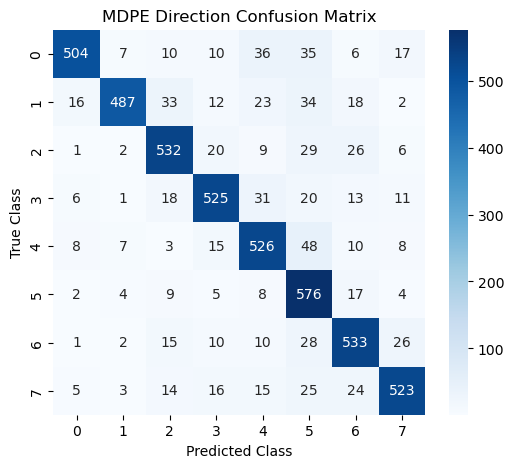


Per-Class Accuracy (%):
class_true
0    80.64
1    77.92
2    85.12
3    84.00
4    84.16
5    92.16
6    85.28
7    83.68
Name: class_correct, dtype: float64


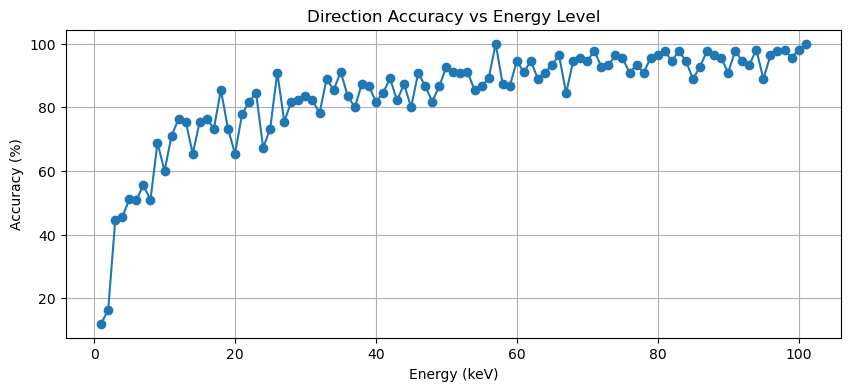


Saved per-class + energy breakdown CSVs.


In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Load results
path = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/results/Dec27_EmbeddingNetHailMary_eval.csv"
df = pd.read_csv(path)

print("Loaded:", df.shape, "rows")
print(df.head())

# =========================
# Overall Accuracy
# =========================
acc = df["class_correct"].mean() * 100
print(f"\nDirection Accuracy: {acc:.2f}%")

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(df["class_true"], df["class_pred"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(8), yticklabels=range(8))
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("MDPE Direction Confusion Matrix")
plt.show()

# =========================
# Per-Class Accuracy Breakdown
# =========================
class_acc = df.groupby("class_true")["class_correct"].mean() * 100
print("\nPer-Class Accuracy (%):")
print(class_acc)

# =========================
# Accuracy vs Energy
# =========================
df["energy_bin"] = df["energy_true"].round(0)  # 1 keV bins
energy_acc = df.groupby("energy_bin")["class_correct"].mean() * 100

plt.figure(figsize=(10,4))
plt.plot(energy_acc.index, energy_acc.values, marker="o")
plt.xlabel("Energy (keV)")
plt.ylabel("Accuracy (%)")
plt.title("Direction Accuracy vs Energy Level")
plt.grid(True)
plt.show()

# =========================
# Save breakdown tables
# =========================
class_acc.to_csv("class_accuracy_breakdown.csv")
energy_acc.to_csv("accuracy_vs_energy.csv")
print("\nSaved per-class + energy breakdown CSVs.")

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP
# ==========================================
# Replace with the actual path to your latest results CSV
results_path = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/results/Dec25mdpe8_eval_results.csv"

try:
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} predictions from {results_path}")
except FileNotFoundError:
    print("Error: File not found. Please check the path.")
    exit()

# ==========================================
# 2. CONFIGURATION
# ==========================================
# Define energy bins (in keV)
# 0-10 is "Blob Zone" (Expect low accuracy)
# 50+ is "Needle Zone" (Expect high accuracy)
bins = [0, 10, 30, 50, 100, 1000]
labels = ["0-10 keV", "10-30 keV", "30-50 keV", "50-100 keV", "100+ keV"]

# Ensure columns are numeric
df["true_energy"] = pd.to_numeric(df["true_energy"])
df["true_angle_class"] = df["true_angle_class"].astype(int)
df["predicted_angle_class"] = df["predicted_angle_class"].astype(int)

# ==========================================
# 3. CALCULATE ACCURACY PER BIN
# ==========================================
df["energy_bin"] = pd.cut(df["true_energy"], bins=bins, labels=labels)

results = []

print("\n" + "="*55)
print(f"{'Energy Range':<15} | {'Accuracy':<10} | {'Tracks':<10} | {'Status'}")
print("="*55)

for label in labels:
    subset = df[df["energy_bin"] == label]
    
    if len(subset) == 0:
        print(f"{label:<15} | {'N/A':<10} | {0:<10} | -")
        continue
        
    # Calculate exact matches
    correct = (subset["true_angle_class"] == subset["predicted_angle_class"]).sum()
    total = len(subset)
    acc = (correct / total) * 100
    
    # Simple status flag
    if acc > 85: status = "EXCELLENT"
    elif acc > 70: status = "GOOD"
    elif acc > 50: status = "OKAY"
    else: status = "BLOB NOISE"
    
    results.append(acc)
    print(f"{label:<15} | {acc:.2f}%     | {total:<10} | {status}")

print("="*55 + "\n")

# ==========================================
# 4. PLOT THE TREND
# ==========================================
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, results, color='#2c7bb6', edgecolor='black', alpha=0.8)

# Add threshold line
plt.axhline(y=80, color='r', linestyle='--', label="80% Target")
plt.axhline(y=12.5, color='gray', linestyle=':', label="Random Guess (12.5%)")

# Labels
plt.title("Directional Accuracy by Energy Level", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlabel("Incident Energy (keV)", fontsize=12)
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Loaded 5000 predictions from /Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/results/Dec25mdpe8_eval_results.csv


KeyError: 'true_energy'

Preprocessing tracks to extract 30D features...
[MDPE] Preprocessed 199964 tracks. Dim: 30 (30D)
Training Random Forest models for importance ranking...


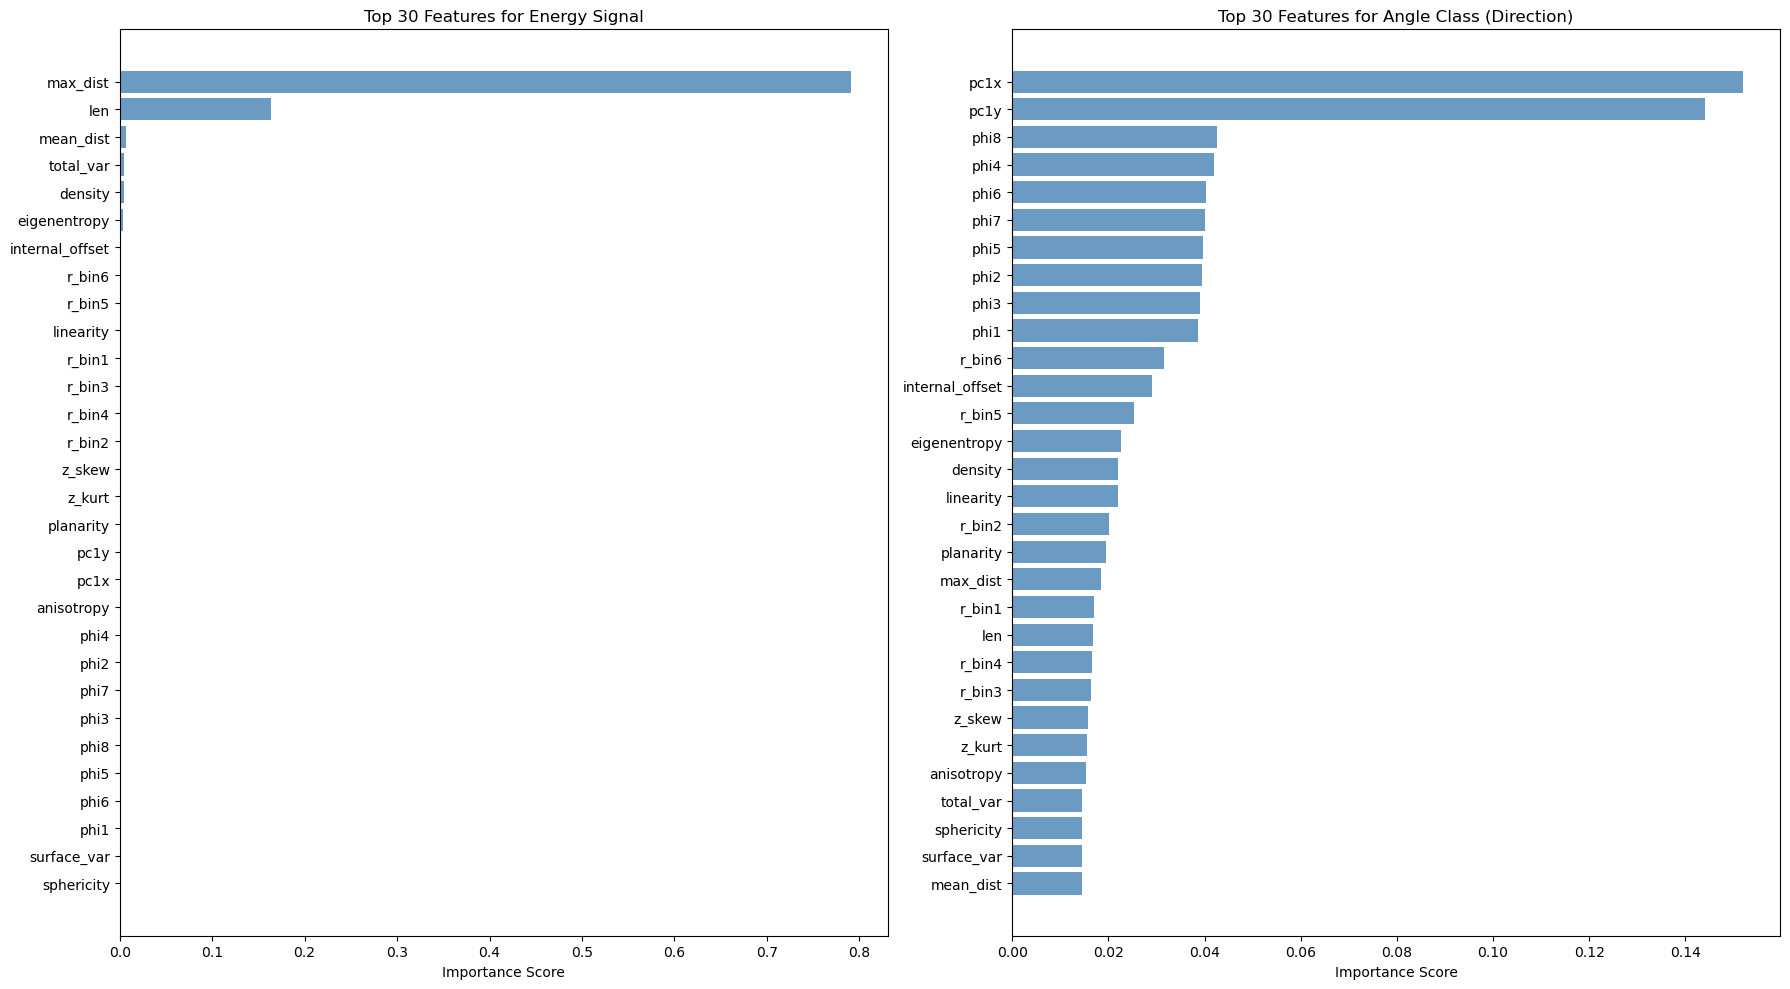

In [70]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# ============================================================
# 1. LOAD AND PREPROCESS A SUBSET
# ============================================================
# Replace with your actual path. We use a subset (e.g., 25k) for speed.
TRAIN_CSV = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/MDPE_TRAIN_200k_ROTATED.csv" 

print("Preprocessing tracks to extract 30D features...")
x_train, theta_train, _, _, _ = preprocess_mdpe(TRAIN_CSV)

# Convert tensors to numpy for Scikit-Learn
X = x_train.numpy()
y_energy = theta_train.numpy()[:, 0]
y_angle = theta_train.numpy()[:, 1]

# ============================================================
# 2. DEFINE FEATURE NAMES (Must match the 30D assembly order)
# ============================================================
f_names = [
    "len", "mean_dist", "max_dist",                     # Scale (3)
    "r_bin1", "r_bin2", "r_bin3", "r_bin4", "r_bin5", "r_bin6", # Radial (6)
    "phi1", "phi2", "phi3", "phi4", "phi5", "phi6", "phi7", "phi8", # Phi (8)
    "linearity", "planarity", "sphericity",             # PCA Shapes (3)
    "anisotropy", "surface_var", "eigenentropy",        # PCA Shapes (3)
    "pc1x", "pc1y",                                     # Directed Spine (2)
    "total_var", "z_skew", "z_kurt",                    # Moments (3)
    "internal_offset", "density"                        # Specificity (2)
]

# ============================================================
# 3. RUN FEATURE IMPORTANCE ANALYSIS
# ============================================================
print("Training Random Forest models for importance ranking...")
# Energy uses a Regressor; Angle Class uses a Classifier
rf_e = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42).fit(X, y_energy)
rf_a = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42).fit(X, y_angle)

# ============================================================
# 4. VISUALIZE RESULTS
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

for ax, model, title in zip([ax1, ax2], [rf_e, rf_a], ["Energy Signal", "Angle Class (Direction)"]):
    importances = model.feature_importances_
    indices = np.argsort(importances)
    ax.barh(range(len(indices)), importances[indices], color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([f_names[i] for i in indices])
    ax.set_title(f"Top 30 Features for {title}")
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

Loaded 5000 predictions from /Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/results/Dec27_EmbeddingNetHailMary_eval.csv

Energy Range    | Accuracy   | Tracks     | Status
0-1 keV         | 0.00%     | 5          | NOISE LIMIT
1-5 keV         | 35.50%     | 200        | STRUGGLING
5-10 keV        | 56.00%     | 250        | OKAY
10-30 keV       | 76.10%     | 1000       | GREAT
30-50 keV       | 85.30%     | 1000       | EXCELLENT
50-100 keV      | 93.48%     | 2500       | EXCELLENT
100+ keV        | 97.78%     | 45         | EXCELLENT



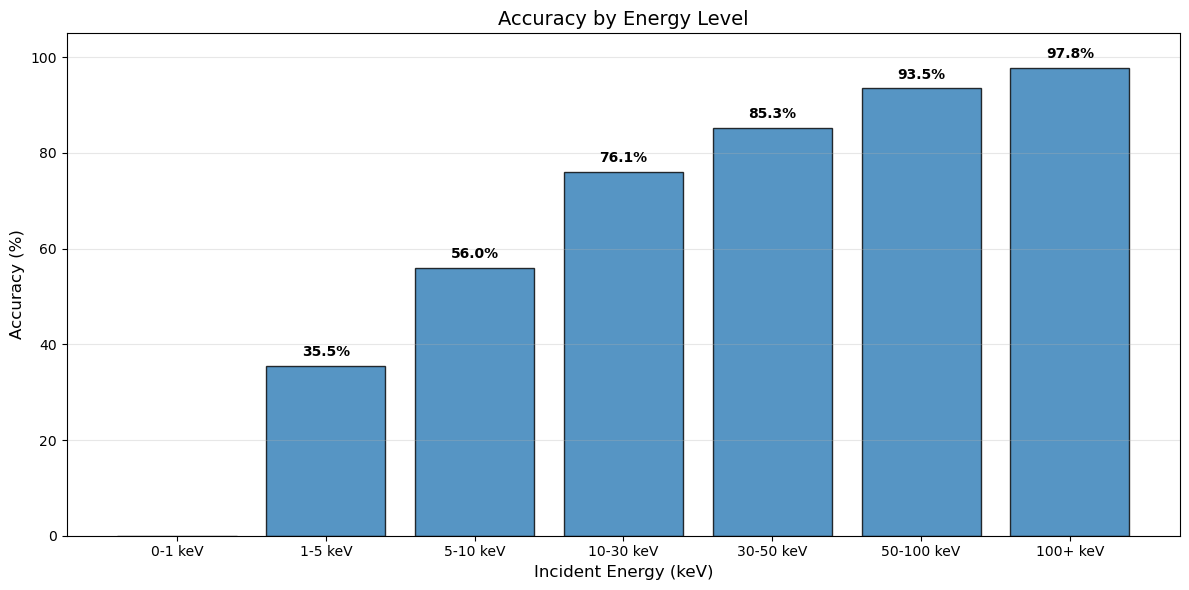

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP
# ==========================================
# Replace with the actual path to your results CSV
results_path = "/Users/cbharathulwar/Documents/Research/Walsworth/Code/SBI/srim-sbi/data/results/Dec27_EmbeddingNetHailMary_eval.csv"

try:
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} predictions from {results_path}")
except FileNotFoundError:
    print("Error: File not found. Please check the path.")
    exit()

# ==========================================
# 2. CONFIGURATION (UPDATED PER DR. ANG)
# ==========================================
# Dr. Ang requested breakdown of <10 keV: 0-1, 1-5, 5-10.
# We keep the higher bins to show the full trend.
bins = [0, 1, 5, 10, 30, 50, 100, 1000]
labels = [
    "0-1 keV", 
    "1-5 keV", 
    "5-10 keV", 
    "10-30 keV", 
    "30-50 keV", 
    "50-100 keV", 
    "100+ keV"
]

# Ensure columns are numeric using YOUR column names
df["energy_true"] = pd.to_numeric(df["energy_true"], errors='coerce')
df["class_true"] = df["class_true"].astype(int)
df["class_pred"] = df["class_pred"].astype(int)

# ==========================================
# 3. CALCULATE ACCURACY PER BIN
# ==========================================
# Binning based on 'energy_true'
df["energy_bin"] = pd.cut(df["energy_true"], bins=bins, labels=labels)

results = []

print("\n" + "="*55)
print(f"{'Energy Range':<15} | {'Accuracy':<10} | {'Tracks':<10} | {'Status'}")
print("="*55)

for label in labels:
    subset = df[df["energy_bin"] == label]
    
    if len(subset) == 0:
        print(f"{label:<15} | {'N/A':<10} | {0:<10} | -")
        results.append(0) # Append 0 to keep plot alignment
        continue
        
    # Calculate exact matches using 'class_true' and 'class_pred'
    correct = (subset["class_true"] == subset["class_pred"]).sum()
    total = len(subset)
    acc = (correct / total) * 100
    
    # Simple status flag
    if acc > 85: status = "EXCELLENT"
    elif acc > 75: status = "GREAT"
    elif acc > 50: status = "OKAY"
    elif acc > 25: status = "STRUGGLING"
    else: status = "NOISE LIMIT"
    
    results.append(acc)
    print(f"{label:<15} | {acc:.2f}%     | {total:<10} | {status}")

print("="*55 + "\n")

# ==========================================
# 4. PLOT THE TREND
# ==========================================
plt.figure(figsize=(12, 6)) # Made figure slightly wider for more bins
bars = plt.bar(labels, results, color='#2c7bb6', edgecolor='black', alpha=0.8)

# Labels
plt.title("Accuracy by Energy Level", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlabel("Incident Energy (keV)", fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    # Only plot text if bar height is > 0
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()